<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/refinement_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip


In [4]:
import zipfile
import os
import glob
import pandas as pd

# Get uploaded ZIP file
zip_file = list(uploaded.keys())[0]

# Extract
extract_path = "/content/underwater_data"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully")

# Find all CSV files
csv_files = glob.glob(
    extract_path + "/**/*.csv",
    recursive=True
)

print("\nCSV files found:", len(csv_files))

for f in csv_files:
    print(f)

ZIP extracted successfully

CSV files found: 8
/content/underwater_data/Underwater-Image-Data-set-main/training_log 6.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 4.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 7.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 3.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 2.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 1.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 5.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 8.csv


In [5]:
all_logs = []

for f in csv_files:
    temp = pd.read_csv(f)
    temp["source_file"] = os.path.basename(f)
    all_logs.append(temp)

df = pd.concat(all_logs, ignore_index=True)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (24915, 6)
Columns: ['epoch', 'step', 'gen_total', 'disc_loss', 'time_s', 'source_file']


In [6]:
df.head()

,epoch,step,gen_total,disc_loss,time_s,source_file
0,62,1,5.130928,0.749042,29.679657,training_log 6.csv
1,62,2,5.337514,0.698042,34.161528,training_log 6.csv
2,62,3,6.094767,0.698099,38.682715,training_log 6.csv
3,62,4,5.333790,0.685004,43.190114,training_log 6.csv
4,62,5,13.008395,0.712128,47.711985,training_log 6.csv


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24915 entries, 0 to 24914
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   epoch        24915 non-null  int64  
 1   step         24915 non-null  int64  
 2   gen_total    24915 non-null  float64
 3   disc_loss    24915 non-null  float64
 4   time_s       24915 non-null  float64
 5   source_file  24915 non-null  object 
dtypes: float64(3), int64(2), object(1)
memory usage: 1.1+ MB
None


In [8]:
print(df.isnull().sum())

epoch          0
step           0
gen_total      0
disc_loss      0
time_s         0
source_file    0
dtype: int64


In [9]:
feature_columns = ["epoch", "step", "disc_loss", "time_s"]
target_column = "gen_total"

X = df[feature_columns].values
y = df[target_column].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24915, 4)
y shape: (24915,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Normalized data shape:", X_scaled.shape)

Normalized data shape: (24915, 4)


In [11]:
SEQUENCE_LENGTH = 10

X_seq = []
y_seq = []

for i in range(len(X_scaled) - SEQUENCE_LENGTH):
    X_seq.append(X_scaled[i:i+SEQUENCE_LENGTH])
    y_seq.append(y[i+SEQUENCE_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence input shape:", X_seq.shape)
print("Sequence target shape:", y_seq.shape)

Sequence input shape: (24905, 10, 4)
Sequence target shape: (24905,)


In [12]:
n = len(X_seq)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (17433, 10, 4) (17433,)
Validation: (3736, 10, 4) (3736,)
Testing: (3736, 10, 4) (3736,)


In [13]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Tensor conversion completed")

Tensor conversion completed


In [14]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [15]:
import torch.nn as nn

class TCNModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv1d(
                input_size, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                64, 64,
                kernel_size=3,
                padding=2,
                dilation=2
            ),
            nn.ReLU(),

            nn.Conv1d(
                64, 32,
                kernel_size=3,
                padding=4,
                dilation=4
            ),
            nn.ReLU()
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Shape: batch, sequence, features
        x = x.transpose(1, 2)

        x = self.network(x)

        # Take final time step
        x = x[:, :, -1]

        return self.fc(x)


input_size = X_train.shape[2]

tcn_model = TCNModel(input_size)

print(tcn_model)

TCNModel(
  (network): Sequential(
    (0): Conv1d(4, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (3): ReLU()
    (4): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (5): ReLU()
  )
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [16]:
tcn_params = sum(
    p.numel()
    for p in tcn_model.parameters()
    if p.requires_grad
)

print("TCN trainable parameters:", tcn_params)

TCN trainable parameters: 19393


In [17]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    tcn_model.parameters(),
    lr=0.001
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [18]:
EPOCHS = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

start_time = time.time()

for epoch in range(EPOCHS):

    # -------- Training --------
    tcn_model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = tcn_model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # -------- Validation --------
    tcn_model.eval()
    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = tcn_model(X_batch)

            loss = criterion(predictions, y_batch)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # -------- Save best model --------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            tcn_model.state_dict(),
            "/content/best_tcn_model.pth"
        )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

runtime = time.time() - start_time

print("\nTraining completed!")
print("Best validation loss:", best_val_loss)
print("Training runtime:", runtime, "seconds")

Epoch [1/30] Train Loss: 52.3251 Val Loss: 45.6731
Epoch [2/30] Train Loss: 49.4983 Val Loss: 32.1136
Epoch [3/30] Train Loss: 46.2440 Val Loss: 33.3196
Epoch [4/30] Train Loss: 45.1992 Val Loss: 32.2779
Epoch [5/30] Train Loss: 43.3239 Val Loss: 32.8122
Epoch [6/30] Train Loss: 42.0408 Val Loss: 30.8562
Epoch [7/30] Train Loss: 41.2054 Val Loss: 33.5465
Epoch [8/30] Train Loss: 40.8218 Val Loss: 27.9432
Epoch [9/30] Train Loss: 40.1177 Val Loss: 32.8294
Epoch [10/30] Train Loss: 39.8874 Val Loss: 28.5032
Epoch [11/30] Train Loss: 39.5771 Val Loss: 34.1014
Epoch [12/30] Train Loss: 39.2900 Val Loss: 26.7889
Epoch [13/30] Train Loss: 39.0799 Val Loss: 33.4244
Epoch [14/30] Train Loss: 38.8550 Val Loss: 25.9972
Epoch [15/30] Train Loss: 38.8152 Val Loss: 27.7340
Epoch [16/30] Train Loss: 38.6668 Val Loss: 26.9021
Epoch [17/30] Train Loss: 38.6027 Val Loss: 26.0956
Epoch [18/30] Train Loss: 38.4920 Val Loss: 26.2657
Epoch [19/30] Train Loss: 38.8911 Val Loss: 24.9686
Epoch [20/30] Train L

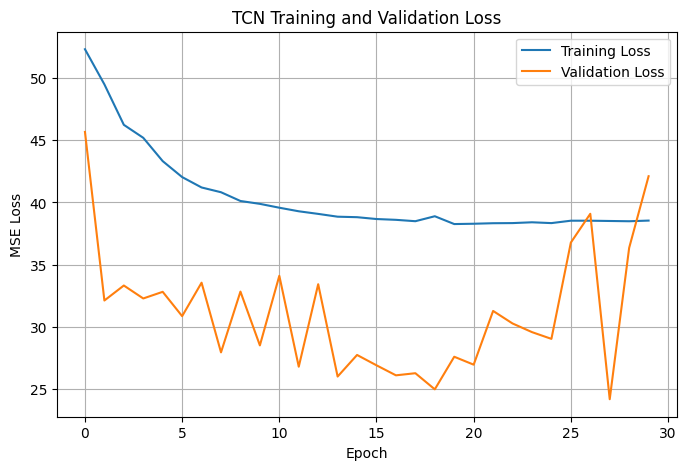

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
import os

print(
    "Best TCN checkpoint exists:",
    os.path.exists("/content/best_tcn_model.pth")
)

Best TCN checkpoint exists: True


In [21]:
tcn_model.load_state_dict(
    torch.load("/content/best_tcn_model.pth")
)

tcn_model.eval()

print("Best TCN checkpoint loaded successfully!")

Best TCN checkpoint loaded successfully!


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = []
actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        pred = tcn_model(X_batch)

        predictions.extend(pred.squeeze().numpy())
        actual.extend(y_batch.squeeze().numpy())

predictions = np.array(predictions)
actual = np.array(actual)

mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

mape = np.mean(
    np.abs((actual - predictions) / (actual + 1e-8))
) * 100

r2 = r2_score(actual, predictions)

print("===== TCN Test Results =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("R²   :", r2)

===== TCN Test Results =====
MAE  : 4.979432582855225
RMSE : 5.831188061744003
MAPE : 72.103294
R²   : -0.35340309143066406


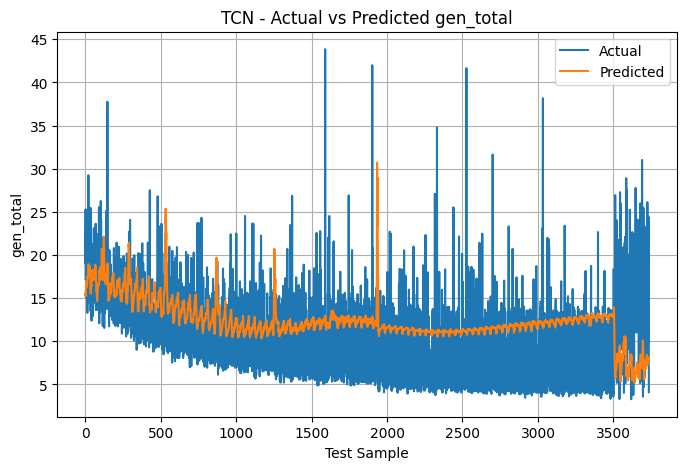

In [23]:
plt.figure(figsize=(8,5))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.xlabel("Test Sample")
plt.ylabel("gen_total")
plt.title("TCN - Actual vs Predicted gen_total")

plt.legend()
plt.grid(True)

plt.show()

In [24]:
tcn_predictions = pd.DataFrame({
    "Actual": actual,
    "Predicted": predictions
})

tcn_predictions.to_csv(
    "/content/tcn_predictions.csv",
    index=False
)

print("TCN predictions saved successfully!")

TCN predictions saved successfully!


In [25]:
refinement_log = pd.DataFrame({
    "Model": ["TCN"],
    "Target": ["gen_total"],
    "Sequence_Length": [10],
    "Parameters": [tcn_params],
    "Runtime_seconds": [runtime],
    "Best_Validation_Loss": [best_val_loss],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

print(refinement_log)

  Model     Target  Sequence_Length  Parameters  Runtime_seconds  \
0   TCN  gen_total               10       19393        89.767733   

   Best_Validation_Loss       MAE      RMSE       MAPE        R2  
0             24.173636  4.979433  5.831188  72.103294 -0.353403  


In [26]:
refinement_log.to_csv(
    "/content/refinement_log.csv",
    index=False
)

print("Refinement log saved!")

Refinement log saved!


In [27]:
import os

files_to_check = [
    "/content/best_tcn_model.pth",
    "/content/tcn_predictions.csv",
    "/content/refinement_log.csv"
]

for f in files_to_check:
    print(os.path.basename(f), ":", os.path.exists(f))

best_tcn_model.pth : True
tcn_predictions.csv : True
refinement_log.csv : True


In [28]:
import os

files_to_check = [
    "/content/best_tcn_model.pth",
    "/content/tcn_predictions.csv",
    "/content/refinement_log.csv"
]

for f in files_to_check:
    print(os.path.basename(f), ":", os.path.exists(f))

best_tcn_model.pth : True
tcn_predictions.csv : True
refinement_log.csv : True


# Refinement Outcome

A Temporal Convolutional Network (TCN) was implemented as an alternative
architecture to the previous GRU model.

The same sequence length and time-based data split were maintained for a
fair comparison.

Training loss and validation loss were tracked throughout training.
Model parameter count and runtime were also recorded.

The best TCN model was selected based on validation performance and saved
as `best_tcn_model.pth`.

The refinement results were saved in `refinement_log.csv`, and test
predictions were saved in `tcn_predictions.csv`.

The Transformer architecture was kept as a stretch-only option.

## Dataset Note

The available dataset contains underwater GAN training logs rather than
SoH/RUL measurements. Therefore, this experiment predicts `gen_total`
and represents an architecture-refinement experiment on GAN training-log
time series, not an SoH/RUL experiment.